# 05_baseline_train_v2.ipynb

Baseline-обучение для **основного** датасета `usct_dataset_v2`.

Что делает ноутбук:
- читает `train / val / test` из готовых `.npz`;
- считает статистики по `train`;
- строит `M_hom_complex` для residual-режима;
- создаёт `Dataset` / `DataLoader`;
- обучает baseline-модель;
- использует `best checkpoint` по `val_loss`;
- считает метрики на `train / val / test`;
- сохраняет модель, метрики и примеры предсказаний.

In [1]:

%pip install -U pip setuptools wheel ipykernel

%pip install --no-cache-dir \
  "jax==0.4.38" \
  "jaxlib==0.4.38" \
  "jax-cuda12-pjrt==0.4.38" \
  "jax-cuda12-plugin[with-cuda]==0.4.38" \
  "equinox==0.11.12" \
  "jaxdf==0.2.8" \
  "jwave==0.2.1"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from huggingface_hub import hf_hub_download

test_speed_path = hf_hub_download(
    repo_id="OpenBreastUS/breast",
    repo_type="dataset",
    filename="breast_test_speed.mat",
)

train_speed_path = hf_hub_download(
    repo_id="OpenBreastUS/breast",
    repo_type="dataset",
    filename="breast_train_speed.mat",
)

print("test_speed_path:", test_speed_path)
print("train_speed_path:", train_speed_path)

test_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_test_speed.mat
train_speed_path: /root/.cache/huggingface/hub/datasets--OpenBreastUS--breast/snapshots/98646e39b9083a5481c6c4070ac2ffbe4f19c393/breast_train_speed.mat


In [3]:
import os
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [4]:
OUT_ROOT = Path("/workspace/usct_dataset_v2")

TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))

assert len(train_files) > 0
assert len(val_files) > 0
assert len(test_files) > 0

train: 6200
val: 1000
test: 800


file: /workspace/usct_dataset_v2/train/sample_00000.npz
keys: ['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x                shape=(2, 16, 256) dtype=float32
c                shape=(192, 192) dtype=float32
receiver_y       shape=(256,) dtype=int64
receiver_x       shape=(256,) dtype=int64
source_ring_idx  shape=(16,) dtype=int64
dx               shape=(2,) dtype=float32
freq_hz          shape=(1,) dtype=float32


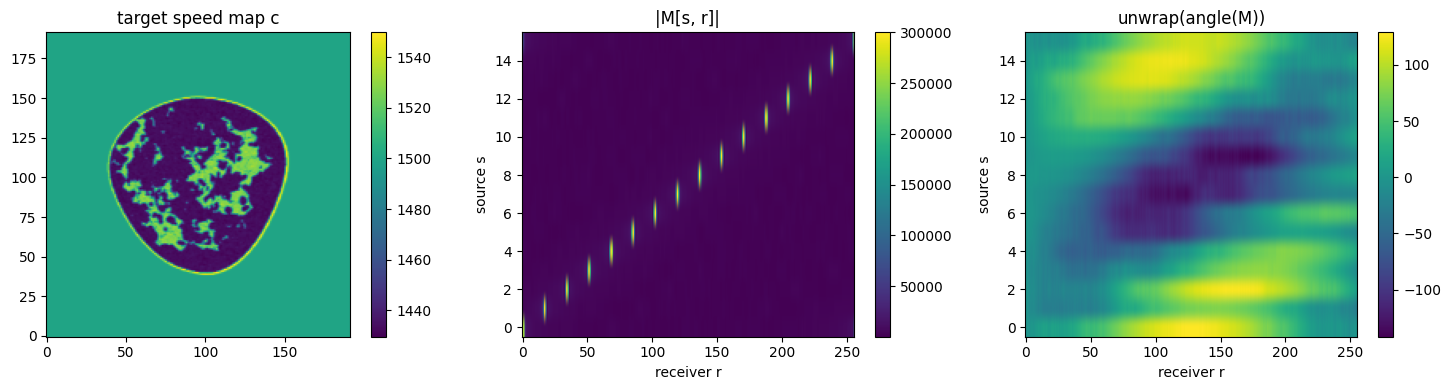

In [5]:
def inspect_npz(path: Path):
    d = np.load(path)
    print("file:", path)
    print("keys:", d.files)
    for k in d.files:
        arr = d[k]
        print(f"{k:16s} shape={arr.shape} dtype={arr.dtype}")

    x = d["x"]
    c = d["c"]
    M = x[0] + 1j * x[1]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    im0 = ax[0].imshow(c, origin="lower")
    ax[0].set_title("target speed map c")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(np.abs(M), aspect="auto", origin="lower")
    ax[1].set_title("|M[s, r]|")
    ax[1].set_xlabel("receiver r")
    ax[1].set_ylabel("source s")
    plt.colorbar(im1, ax=ax[1])

    phase = np.unwrap(np.angle(M), axis=1)
    im2 = ax[2].imshow(phase, aspect="auto", origin="lower")
    ax[2].set_title("unwrap(angle(M))")
    ax[2].set_xlabel("receiver r")
    ax[2].set_ylabel("source s")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

inspect_npz(train_files[0])

In [6]:
def scan_dataset_stats(paths):
    c_min = float("inf")
    c_max = float("-inf")
    x_scales = []

    for p in paths:
        d = np.load(p)
        x = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)

        c_min = min(c_min, float(c.min()))
        c_max = max(c_max, float(c.max()))
        x_scales.append(float(np.max(np.abs(x))))

    return {
        "c_min": c_min,
        "c_max": c_max,
        "x_scale_min": min(x_scales),
        "x_scale_max": max(x_scales),
        "x_scale_mean": float(np.mean(x_scales)),
    }

stats = scan_dataset_stats(train_files)
stats

{'c_min': 1404.1473388671875,
 'c_max': 1598.34423828125,
 'x_scale_min': 290344.0,
 'x_scale_max': 321105.0625,
 'x_scale_mean': 296926.66734879033}

In [7]:
sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

CFG = {
    "H": H,
    "W": W,
    "freq_hz": freq_hz,
    "density": 1000.0,
    "pml_size": 16,
    "num_sources": int(S),
    "num_receivers": int(R),
    "source_sigma_px": 1.8,
}

receiver_y = sample0["receiver_y"].astype(np.int64)
receiver_x = sample0["receiver_x"].astype(np.int64)
source_ring_idx = sample0["source_ring_idx"].astype(np.int64)

print("CFG:", CFG)
print("dx:", dx)

CFG: {'H': 192, 'W': 192, 'freq_hz': 500000.0, 'density': 1000.0, 'pml_size': 16, 'num_sources': 16, 'num_receivers': 256, 'source_sigma_px': 1.8}
dx: (np.float32(0.00075), np.float32(0.00075))


In [8]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [9]:
def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

@jit
def solve_helmholtz_jit(medium, omega, src):
    return helmholtz_solver(medium, omega, src)

def simulate_measurement_matrix_from_geometry(c_map, receiver_y, receiver_x, source_ring_idx, dx, cfg):
    H, W = c_map.shape
    domain = Domain((H, W), dx)
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=cfg["density"],
        pml_size=cfg["pml_size"],
    )

    omega = 2 * np.pi * cfg["freq_hz"]
    M = np.zeros((len(source_ring_idx), len(receiver_y)), dtype=np.complex64)

    for i, ridx in enumerate(source_ring_idx):
        y0 = int(receiver_y[ridx])
        x0 = int(receiver_x[ridx])

        src_np = gaussian_source(H, W, y0, x0, sigma=cfg["source_sigma_px"])
        src_field = jnp.array(src_np, dtype=jnp.complex64)
        src = FourierSeries(jnp.expand_dims(src_field, -1), domain)

        field = solve_helmholtz_jit(medium, omega, src * omega)
        u = np.array(field.params[..., 0])
        M[i] = u[receiver_y, receiver_x]

    return M

In [10]:
c_hom = np.full((H, W), 1500.0, dtype=np.float32)

M_hom_complex = simulate_measurement_matrix_from_geometry(
    c_hom,
    receiver_y=receiver_y,
    receiver_x=receiver_x,
    source_ring_idx=source_ring_idx,
    dx=dx,
    cfg=CFG,
)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)

/tmp/ipykernel_12466/2885456303.py:13: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom_complex: (16, 256) complex64


In [11]:
def mask_self_receivers(M: np.ndarray, source_ring_idx: np.ndarray, half_width: int = 2) -> np.ndarray:
    M = M.copy()
    S, R = M.shape

    if len(source_ring_idx) != S:
        raise ValueError(f"source_ring_idx length {len(source_ring_idx)} != number of sources {S}")

    for s in range(S):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R
            M[s, rr] = 0.0 + 0.0j

    return M

In [12]:
class USCTPairDataset(Dataset):
    def __init__(
        self,
        paths,
        c_min,
        c_max,
        M_hom_complex,
        use_residual=True,
        mask_half_width=2,
    ):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)

        if use_residual and M_hom_complex is None:
            raise ValueError("Residual mode requires non-None M_hom_complex")

        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]

        if self.use_residual:
            M = M - self.M_hom_complex

        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x = np.stack([M.real, M.imag], axis=0).astype(np.float32)

        x_scale = float(np.percentile(np.abs(x), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x = x / x_scale

        c = (c - self.c_min) / self.c_range

        x = torch.from_numpy(x)
        c = torch.from_numpy(c).unsqueeze(0)

        meta = {
            "path": str(self.paths[idx]),
            "x_scale": x_scale,
        }
        return x, c, meta

ds_train = USCTPairDataset(train_files, stats["c_min"], stats["c_max"], M_hom_complex, True, 2)
ds_val = USCTPairDataset(val_files, stats["c_min"], stats["c_max"], M_hom_complex, True, 2)
ds_test = USCTPairDataset(test_files, stats["c_min"], stats["c_max"], M_hom_complex, True, 2)

x0, c0, meta0 = ds_train[0]
print("x0:", x0.shape, x0.dtype)
print("c0:", c0.shape, c0.dtype)
print(meta0)
print("sizes:", len(ds_train), len(ds_val), len(ds_test))

x0: torch.Size([2, 16, 256]) torch.float32
c0: torch.Size([1, 192, 192]) torch.float32
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.64208984375}
sizes: 6200 1000 800


In [13]:
BATCH_SIZE = 8
NUM_WORKERS = 4

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(1, out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class SimpleUSCTBaseline(nn.Module):
    def __init__(self, in_ch=2):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, 32, stride=1)
        self.enc2 = ConvBlock(32, 64, stride=2)
        self.enc3 = ConvBlock(64, 128, stride=2)
        self.enc4 = ConvBlock(128, 128, stride=2)

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 2 * 32, 128 * 12 * 12),
            nn.GELU(),
        )

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.enc1(x)
        z = self.enc2(z)
        z = self.enc3(z)
        z = self.enc4(z)
        z = self.flatten(z)
        z = self.fc(z)
        z = z.view(x.shape[0], 128, 12, 12)
        return self.dec(z)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUSCTBaseline().to(device)

with torch.no_grad():
    y = model(x0.unsqueeze(0).to(device))
print("pred shape:", y.shape)

pred shape: torch.Size([1, 1, 192, 192])


In [15]:
def denorm_c(c_norm, c_min, c_max):
    return c_norm * (c_max - c_min) + c_min

def batch_to_device(batch, device):
    x, c, meta = batch
    return x.to(device), c.to(device), meta

def show_prediction(model, dataset, idx=0, device="cpu", c_min=None, c_max=None):
    model.eval()
    x, c, meta = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu()[0, 0]

    target = c[0]
    pred_np = pred.numpy()
    target_np = target.numpy()

    if c_min is not None and c_max is not None:
        pred_vis = denorm_c(pred_np, c_min, c_max)
        target_vis = denorm_c(target_np, c_min, c_max)
    else:
        pred_vis = pred_np
        target_vis = target_np

    err = np.abs(pred_vis - target_vis)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(target_vis, origin="lower")
    ax[0].set_title("target")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(pred_vis, origin="lower")
    ax[1].set_title("prediction")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

def train_model(model, train_loader, val_loader=None, epochs=300, lr=1e-3, device="cpu", patience=40):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_epoch = -1
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            x, c, _ = batch_to_device(batch, device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, c)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        history["train_loss"].append(train_loss)

        val_loss = None
        if val_loader is not None:
            model.eval()
            val_losses = []
            with torch.no_grad():
                for batch in val_loader:
                    x, c, _ = batch_to_device(batch, device)
                    pred = model(x)
                    loss = criterion(pred, c)
                    val_losses.append(loss.item())
            val_loss = float(np.mean(val_losses))
            history["val_loss"].append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                best_epoch = epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            if val_loss is None:
                print(f"epoch {epoch:4d} | train_loss={train_loss:.6f}")
            else:
                print(f"epoch {epoch:4d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | best_epoch={best_epoch}")

        if val_loader is not None and no_improve >= patience:
            print(f"Early stopping at epoch {epoch}, best_epoch={best_epoch}, best_val={best_val:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_epoch, best_val

def plot_history(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    if len(history["val_loss"]) > 0:
        plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title("training history")
    plt.legend()
    plt.show()

def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def evaluate_dataset(model, dataset, c_min, c_max, device):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)

    with torch.no_grad():
        for i in range(len(dataset)):
            x, c, meta = dataset[i]
            pred = model(x.unsqueeze(0).to(device)).cpu()[0, 0].numpy()

            target = c[0].numpy()
            pred_phys = denorm_c(pred, c_min, c_max)
            target_phys = denorm_c(target, c_min, c_max)

            m = compute_metrics(pred_phys, target_phys, data_range=data_range)
            m["index"] = i
            m["path"] = meta["path"]
            metrics_list.append(m)

    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))

    return metrics_list, summary

def save_prediction_figure(model, dataset, idx, out_path, device, c_min, c_max):
    model.eval()
    x, c, meta = dataset[idx]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu()[0, 0].numpy()

    target = c[0].numpy()
    pred_phys = denorm_c(pred, c_min, c_max)
    target_phys = denorm_c(target, c_min, c_max)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title("target")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("prediction")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

epoch    1 | train_loss=0.021608
epoch   10 | train_loss=0.009152
epoch   20 | train_loss=0.005365
epoch   30 | train_loss=0.003535
epoch   40 | train_loss=0.002129
epoch   50 | train_loss=0.001140
epoch   60 | train_loss=0.000587
epoch   70 | train_loss=0.000323
epoch   80 | train_loss=0.000187
epoch   90 | train_loss=0.000120
epoch  100 | train_loss=0.000179
epoch  110 | train_loss=0.000068
epoch  120 | train_loss=0.000060
epoch  130 | train_loss=0.000046
epoch  140 | train_loss=0.000032
epoch  150 | train_loss=0.000026
epoch  160 | train_loss=0.000022
epoch  170 | train_loss=0.000019
epoch  180 | train_loss=0.000016
epoch  190 | train_loss=0.000014
epoch  200 | train_loss=0.000012


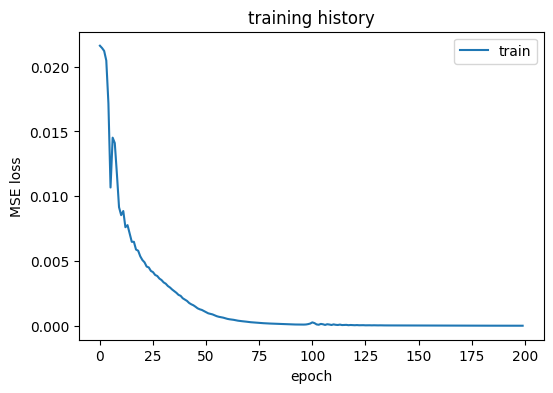

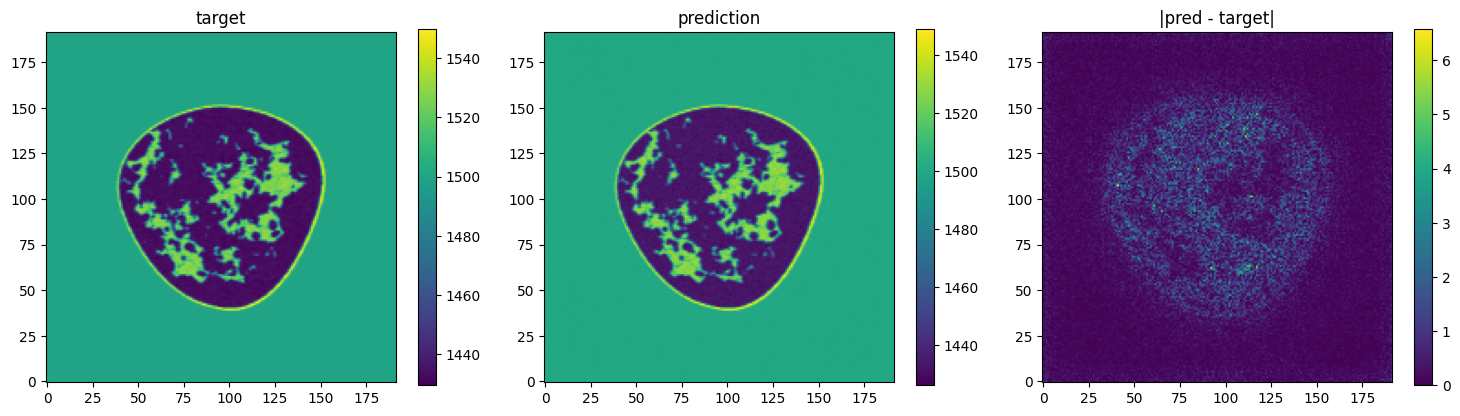

In [16]:
one_file = [train_files[0]]
ds_one = USCTPairDataset(one_file, stats["c_min"], stats["c_max"], M_hom_complex, True, 2)
loader_one = DataLoader(ds_one, batch_size=1, shuffle=True)

model_one = SimpleUSCTBaseline().to(device)
history_one, best_epoch_one, best_val_one = train_model(
    model_one,
    loader_one,
    val_loader=None,
    epochs=200,
    lr=1e-3,
    device=device,
    patience=20,
)
plot_history(history_one)
show_prediction(model_one, ds_one, idx=0, device=device, c_min=stats["c_min"], c_max=stats["c_max"])

/venv/main/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/venv/main/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


epoch    1 | train_loss=0.007250 | val_loss=0.005216 | best_epoch=1
epoch   10 | train_loss=0.002161 | val_loss=0.002207 | best_epoch=10
epoch   30 | train_loss=0.001158 | val_loss=0.001556 | best_epoch=30
epoch   40 | train_loss=0.000989 | val_loss=0.001456 | best_epoch=39
epoch   50 | train_loss=0.000877 | val_loss=0.001391 | best_epoch=50
epoch   60 | train_loss=0.000799 | val_loss=0.001370 | best_epoch=59
epoch   70 | train_loss=0.000739 | val_loss=0.001321 | best_epoch=68
epoch   80 | train_loss=0.000693 | val_loss=0.001280 | best_epoch=80
epoch   90 | train_loss=0.000656 | val_loss=0.001268 | best_epoch=88
epoch  100 | train_loss=0.000627 | val_loss=0.001255 | best_epoch=94
epoch  110 | train_loss=0.000598 | val_loss=0.001258 | best_epoch=109
epoch  120 | train_loss=0.000574 | val_loss=0.001225 | best_epoch=120
epoch  130 | train_loss=0.000556 | val_loss=0.001224 | best_epoch=129
epoch  140 | train_loss=0.000540 | val_loss=0.001230 | best_epoch=136
epoch  150 | train_loss=0.00052

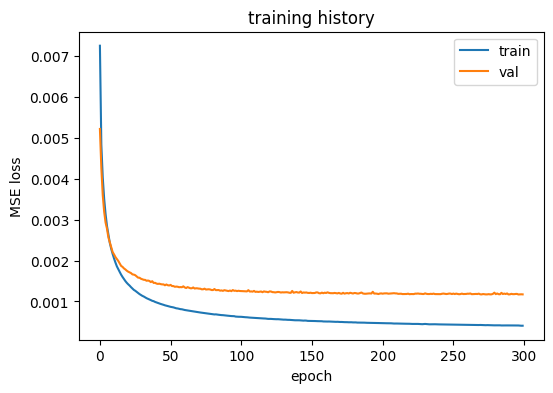

best_epoch_all: 297
best_val_all: 0.0011710899574682116


In [17]:
model_all = SimpleUSCTBaseline().to(device)

history_all, best_epoch_all, best_val_all = train_model(
    model_all,
    train_loader,
    val_loader=val_loader,
    epochs=300,
    lr=1e-3,
    device=device,
    patience=40,
)

plot_history(history_all)
print("best_epoch_all:", best_epoch_all)
print("best_val_all:", best_val_all)

In [18]:
train_metrics_list, train_summary = evaluate_dataset(model_all, ds_train, stats["c_min"], stats["c_max"], device)
val_metrics_list, val_summary = evaluate_dataset(model_all, ds_val, stats["c_min"], stats["c_max"], device)
test_metrics_list, test_summary = evaluate_dataset(model_all, ds_test, stats["c_min"], stats["c_max"], device)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))

print("VAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))

print("TEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 15.295508257804379,
  "mse_std": 5.0290905843217,
  "rmse_mean": 3.8597160471639325,
  "rmse_std": 0.6309518926681827,
  "relative_l2_mean": 0.0025867605164098823,
  "relative_l2_std": 0.0004236534427814096,
  "psnr_mean": 34.14885394711539,
  "psnr_std": 1.413487894425912
}
VAL SUMMARY
{
  "mse_mean": 44.16377973794937,
  "mse_std": 62.912886679085794,
  "rmse_mean": 5.625781056642532,
  "rmse_std": 3.5375651488811526,
  "relative_l2_mean": 0.003771296947961673,
  "relative_l2_std": 0.002372930954390684,
  "psnr_mean": 31.97984006125693,
  "psnr_std": 4.226849610539662
}
TEST SUMMARY
{
  "mse_mean": 377.7124176120758,
  "mse_std": 194.93999342654325,
  "rmse_mean": 18.74002532362938,
  "rmse_std": 5.150132917873968,
  "relative_l2_mean": 0.012559098158380948,
  "relative_l2_std": 0.0034481811267303964,
  "psnr_mean": 20.6669431486316,
  "psnr_std": 2.556379342781485
}


VAL predictions
val example 0


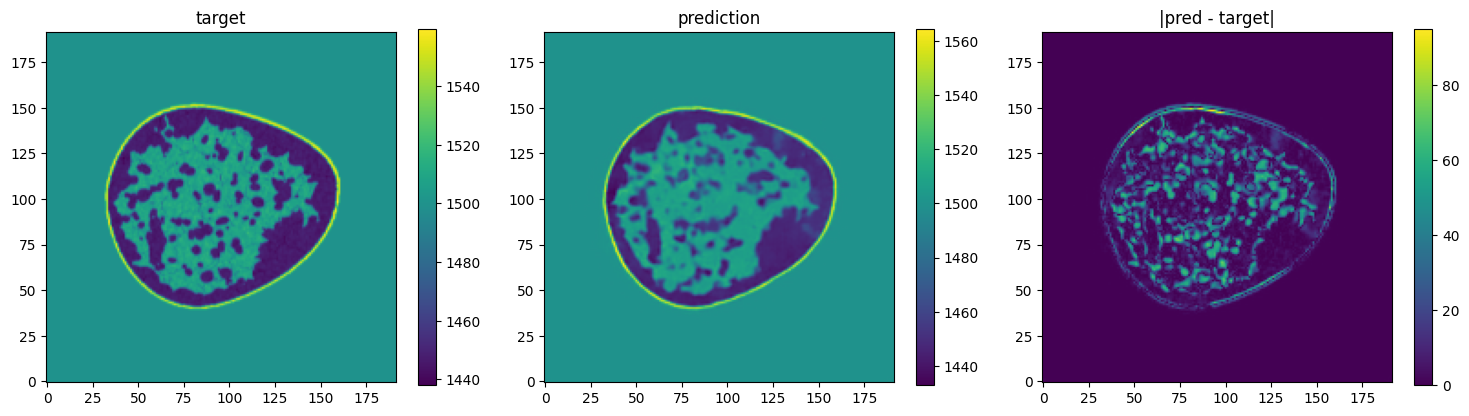

val example 1


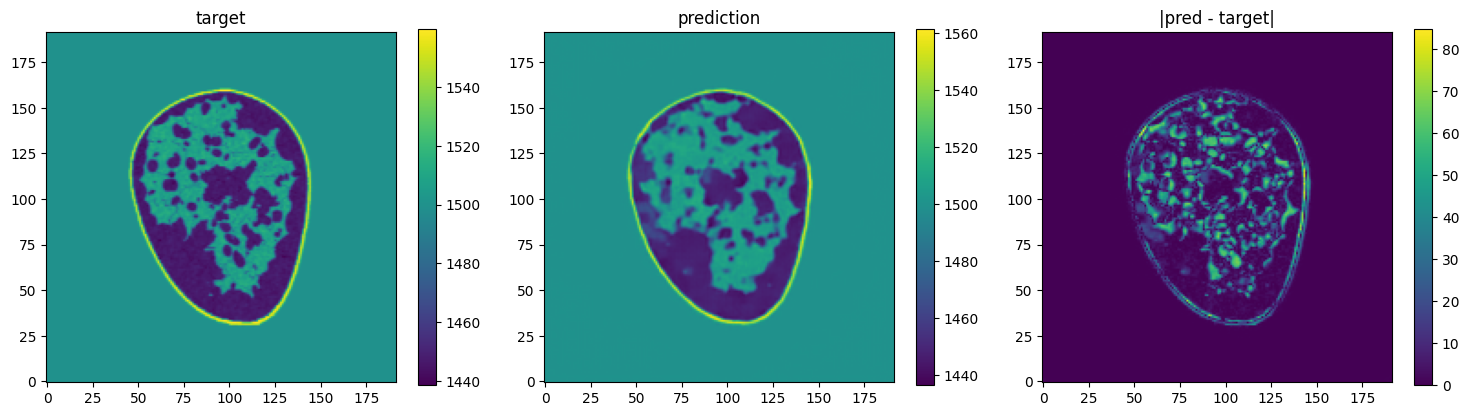

val example 2


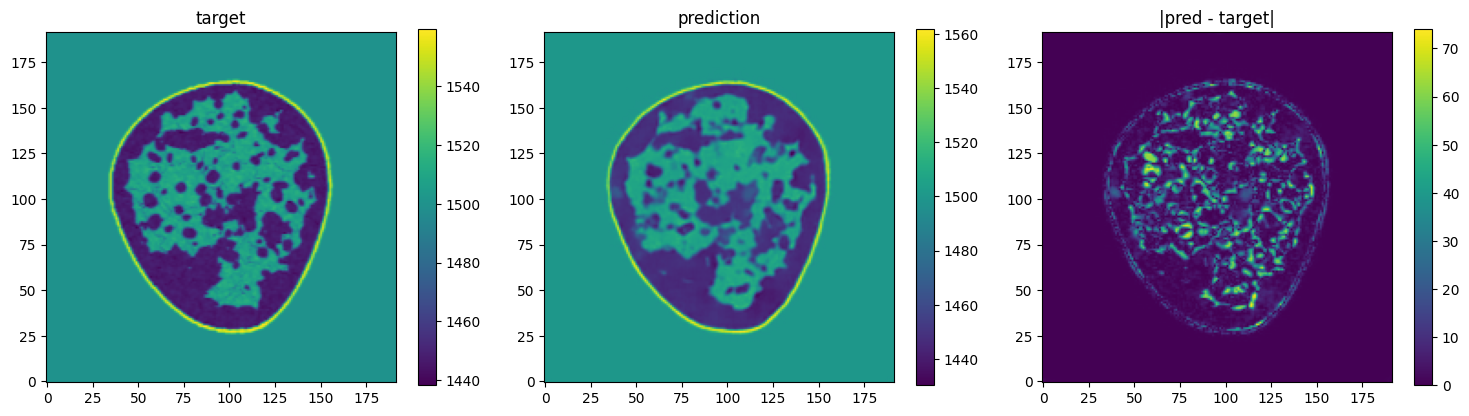

TEST predictions
test example 0


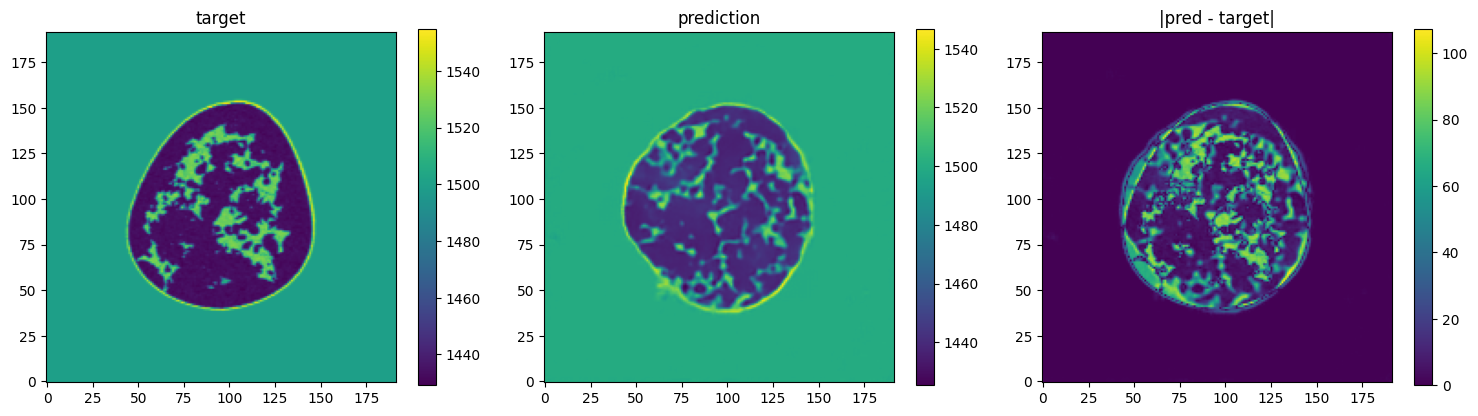

test example 1


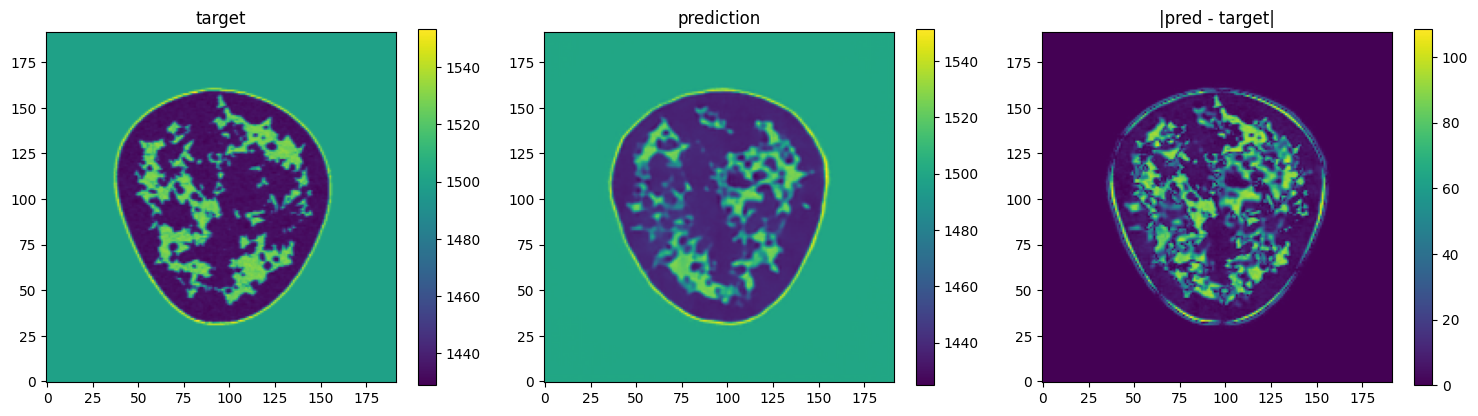

test example 2


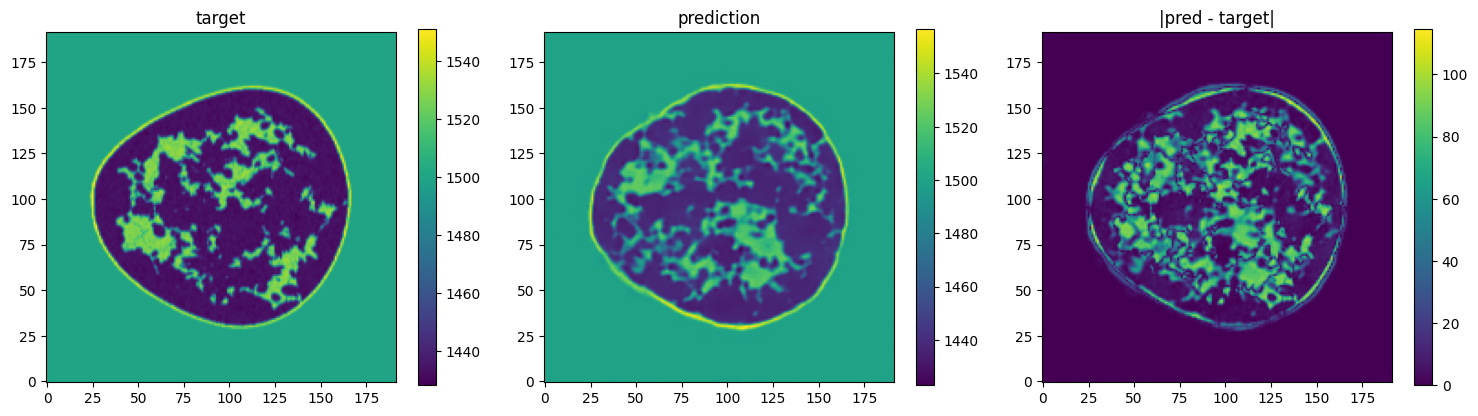

In [19]:
print("VAL predictions")
for i in range(min(3, len(ds_val))):
    print(f"val example {i}")
    show_prediction(model_all, ds_val, idx=i, device=device, c_min=stats["c_min"], c_max=stats["c_max"])

print("TEST predictions")
for i in range(min(3, len(ds_test))):
    print(f"test example {i}")
    show_prediction(model_all, ds_test, idx=i, device=device, c_min=stats["c_min"], c_max=stats["c_max"])

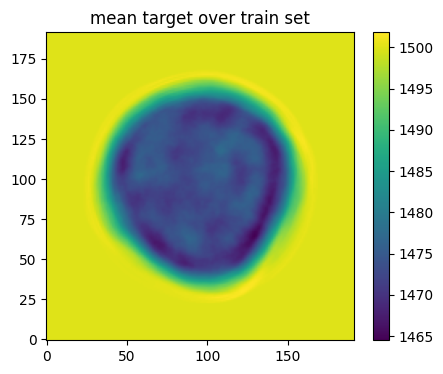

In [20]:
def compute_mean_c(paths):
    cs = []
    for p in paths:
        d = np.load(p)
        cs.append(d["c"].astype(np.float32))
    return np.mean(np.stack(cs, axis=0), axis=0)

mean_c_train = compute_mean_c(train_files)

plt.figure(figsize=(5, 4))
plt.imshow(mean_c_train, origin="lower")
plt.title("mean target over train set")
plt.colorbar()
plt.show()

In [21]:
RUN_NAME = "baseline_residual_v2_main"
REF_DIR = Path("/workspace/reference_points") / RUN_NAME
REF_DIR.mkdir(parents=True, exist_ok=True)

experiment_config = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "model_name": "SimpleUSCTBaseline",
    "input_type": "residual",
    "input_formula": "M_res = M - M_hom",
    "mask_self_receivers": True,
    "mask_half_width": 2,
    "target": "speed_map",
    "target_shape": [H, W],
    "input_shape": list(sample0["x"].shape),
    "num_train_examples": len(train_files),
    "num_val_examples": len(val_files),
    "num_test_examples": len(test_files),
    "best_epoch": int(best_epoch_all) if best_epoch_all is not None else None,
    "best_val_loss_norm_mse": float(best_val_all) if best_val_all is not None else None,
    "c_min": float(stats["c_min"]),
    "c_max": float(stats["c_max"]),
}

with open(REF_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)
with open(REF_DIR / "metrics_train_summary.json", "w", encoding="utf-8") as f:
    json.dump(train_summary, f, ensure_ascii=False, indent=2)
with open(REF_DIR / "metrics_val_summary.json", "w", encoding="utf-8") as f:
    json.dump(val_summary, f, ensure_ascii=False, indent=2)
with open(REF_DIR / "metrics_test_summary.json", "w", encoding="utf-8") as f:
    json.dump(test_summary, f, ensure_ascii=False, indent=2)

torch.save(
    {
        "model_state_dict": model_all.state_dict(),
        "stats": stats,
        "best_epoch": best_epoch_all,
        "best_val": best_val_all,
        "experiment_config": experiment_config,
    },
    REF_DIR / "baseline_model.pt",
)

save_prediction_figure(model_all, ds_train, 0, REF_DIR / "train_pred_00.png", device, stats["c_min"], stats["c_max"])
save_prediction_figure(model_all, ds_val, 0, REF_DIR / "val_pred_00.png", device, stats["c_min"], stats["c_max"])
save_prediction_figure(model_all, ds_test, 0, REF_DIR / "test_pred_00.png", device, stats["c_min"], stats["c_max"])

plt.figure(figsize=(5, 4))
plt.imshow(mean_c_train, origin="lower")
plt.title("mean target over train set")
plt.colorbar()
plt.tight_layout()
plt.savefig(REF_DIR / "mean_target_train.png", dpi=150, bbox_inches="tight")
plt.close()

print("saved artifacts to:", REF_DIR)

saved artifacts to: /workspace/reference_points/baseline_residual_v2_main
